# Temporal Analysis

Yearly/monthly topic frequencies from `tovima_final.csv`.
2023 covers Jan-Jul only — annotated or share-normalized wherever years are compared.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Load

In [2]:
df = pd.read_csv("tovima_final.csv", encoding="utf-32", sep="\t")
df["Date_parsed"] = pd.to_datetime(df["Date_parsed"], utc=True, format="mixed")
df["Month"] = df["Date_parsed"].dt.to_period("M")

print(f"Rows: {len(df)}")
print(df["Year"].value_counts().sort_index().to_string())

Rows: 13637
Year
2018    2248
2019    2625
2020    2437
2021    2440
2022    2545
2023    1342


/tmp/ipykernel_540/1523577377.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["Month"] = df["Date_parsed"].dt.to_period("M")


## 2. Overall list activity

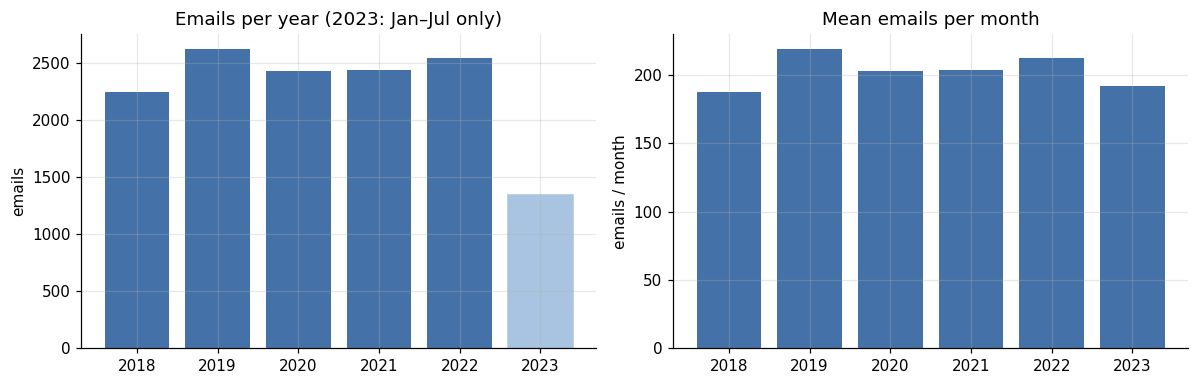

Year
2018    187.3
2019    218.8
2020    203.1
2021    203.3
2022    212.1
2023    191.7


In [3]:
yearly = df.groupby("Year").size()
months_covered = {2018: 12, 2019: 12, 2020: 12, 2021: 12, 2022: 12, 2023: 7}
monthly_rate = yearly / pd.Series(months_covered)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
bars = axes[0].bar(yearly.index.astype(str), yearly.values, color="#4472a8")
bars[-1].set_color("#a8c4e0")
bars[-1].set_hatch("//")
axes[0].set_title("Emails per year (2023: Jan–Jul only)")
axes[0].set_ylabel("emails")

axes[1].bar(monthly_rate.index.astype(str), monthly_rate.values, color="#4472a8")
axes[1].set_title("Mean emails per month")
axes[1].set_ylabel("emails / month")
plt.tight_layout()
plt.savefig("fig_temporal_volume.png", bbox_inches="tight")
plt.show()

print(monthly_rate.round(1).to_string())

## 3. Topic composition per year

In [4]:
comp = df.groupby(["Year", "major_topic"]).size().unstack(fill_value=0)
comp_share = comp.div(comp.sum(axis=1), axis=0) * 100

# order topics by overall size
topic_order = df["major_topic"].value_counts().index.tolist()
comp = comp[topic_order]
comp_share = comp_share[topic_order]

print("Share of yearly traffic (%):")
print(comp_share.round(1).T.to_string())
comp_share.round(2).T.to_csv("topic_share_by_year.csv", encoding="utf-8-sig")
comp.T.to_csv("topic_counts_by_year.csv", encoding="utf-8-sig")

Share of yearly traffic (%):
Year                                2018  2019  2020  2021  2022  2023
major_topic                                                           
Academic Events                     27.0  23.2  20.8  26.3  24.0  30.3
Noise                               15.0  17.4  15.1  13.9  13.0  13.1
Campus Life                         15.0  10.6  10.4   9.3  12.4  12.0
University Administration            8.5  13.4  12.6  11.4   8.4   7.6
Research & Funding                   9.0   7.3   6.8   6.7   5.8   5.5
Labour & Union Affairs               5.8   5.0   5.5   7.6   9.2   8.9
Elections & Governance               5.7   7.9   8.9   5.0   6.9   2.5
Postgraduate Programmes              5.2   3.9   3.1   3.2   3.7   3.1
Health & COVID                       1.4   1.1   5.5   4.2   4.2   4.4
Informal Discussion                  1.0   4.6   4.7   4.2   2.1   2.3
Innovation & Entrepreneurship        2.6   2.3   1.2   1.4   1.5   2.7
University Rankings & Distinctions   0.4   0.9  

## 4. Trend chart — major topics over time

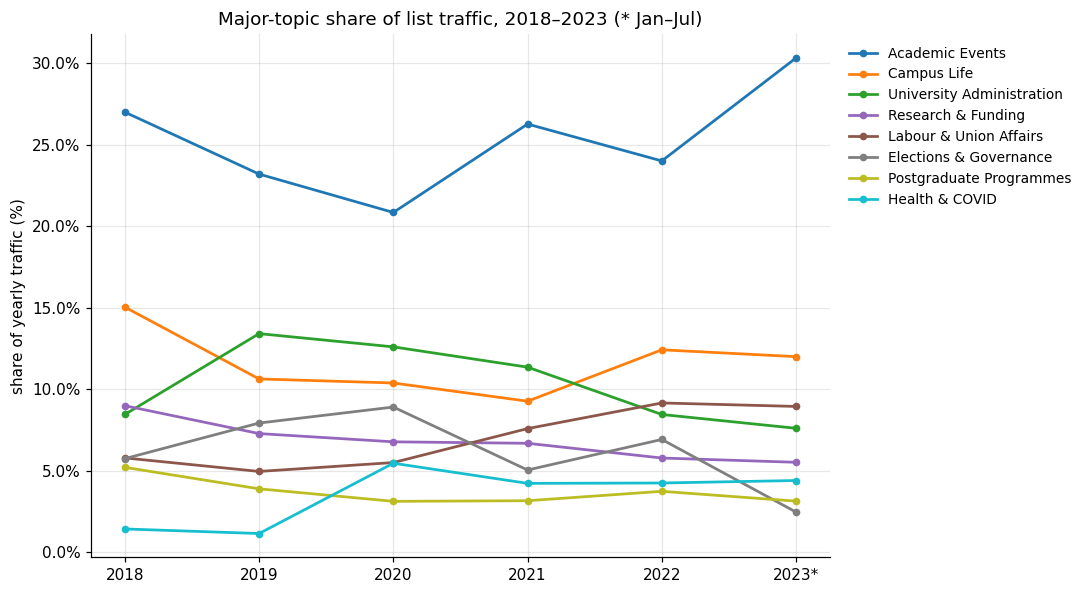

In [5]:
TOP_N = 8
top_topics = [t for t in topic_order if t != "Noise"][:TOP_N]

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, TOP_N))
for topic, c in zip(top_topics, colors):
    ax.plot(comp_share.index, comp_share[topic], marker="o", ms=4,
            label=topic, color=c, lw=1.8)
ax.set_ylabel("share of yearly traffic (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(comp_share.index)
labels = [str(y) + ("*" if y == 2023 else "") for y in comp_share.index]
ax.set_xticklabels(labels)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
ax.set_title("Major-topic share of list traffic, 2018–2023 (* Jan–Jul)")
plt.tight_layout()
plt.savefig("fig_topic_shares.png", bbox_inches="tight")
plt.show()

## 5. COVID-19 at monthly resolution

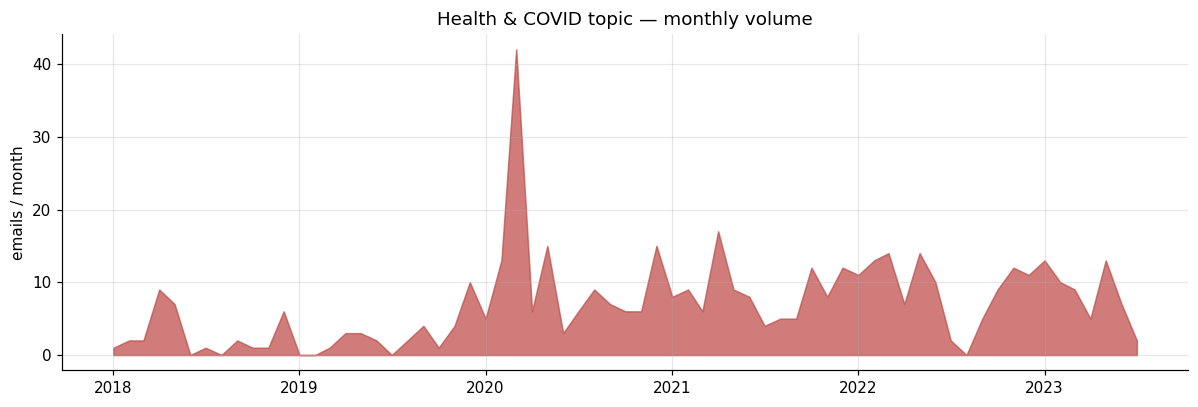

Peak month: 2020-03 (42 emails)
2019 total: 30
2020 total: 133
2021 total: 103
2022 total: 108
2023 (Jan–Jul): 59


In [6]:
covid_monthly = (df[df["major_topic"] == "Health & COVID"]
                 .groupby("Month").size())
all_months = pd.period_range(df["Month"].min(), df["Month"].max(), freq="M")
covid_monthly = covid_monthly.reindex(all_months, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(covid_monthly.index.to_timestamp(), covid_monthly.values,
                color="#c0504d", alpha=0.75)
ax.set_ylabel("emails / month")
ax.set_title("Health & COVID topic — monthly volume")
plt.tight_layout()
plt.savefig("fig_covid_monthly.png", bbox_inches="tight")
plt.show()

peak = covid_monthly.idxmax()
print(f"Peak month: {peak} ({covid_monthly.max()} emails)")
print(f"2019 total: {covid_monthly[covid_monthly.index.year == 2019].sum()}")
print(f"2020 total: {covid_monthly[covid_monthly.index.year == 2020].sum()}")
print(f"2021 total: {covid_monthly[covid_monthly.index.year == 2021].sum()}")
print(f"2022 total: {covid_monthly[covid_monthly.index.year == 2022].sum()}")
print(f"2023 (Jan–Jul): {covid_monthly[covid_monthly.index.year == 2023].sum()}")

## 6. Elections & Governance: institutional cycles

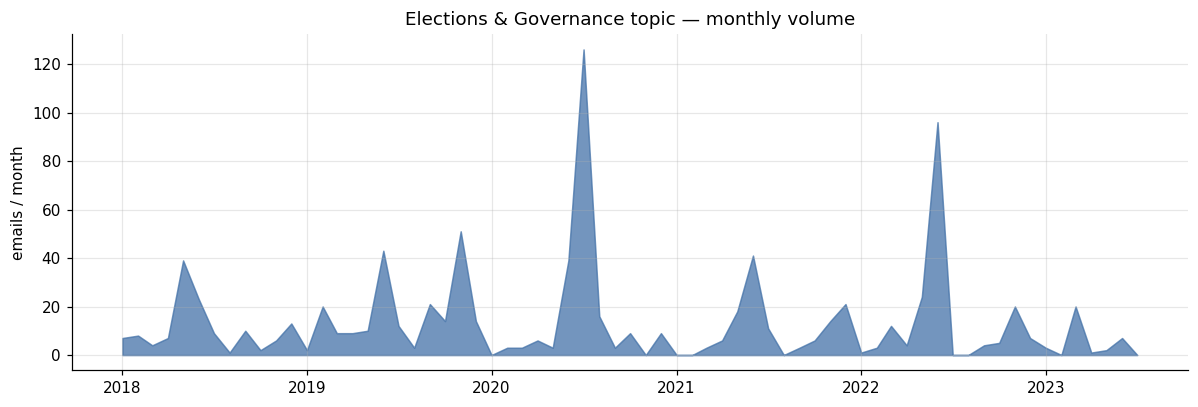

Top 6 election months:
2020-07    126
2022-06     96
2019-11     51
2019-06     43
2021-06     41
2020-06     39
Freq: M


In [7]:
elec_monthly = (df[df["major_topic"] == "Elections & Governance"]
                .groupby("Month").size().reindex(all_months, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(elec_monthly.index.to_timestamp(), elec_monthly.values,
                color="#4472a8", alpha=0.75)
ax.set_ylabel("emails / month")
ax.set_title("Elections & Governance topic — monthly volume")
plt.tight_layout()
plt.savefig("fig_elections_monthly.png", bbox_inches="tight")
plt.show()

print("Top 6 election months:")
print(elec_monthly.sort_values(ascending=False).head(6).to_string())

## 7. Largest composition shifts, first vs last full year

In [8]:
delta = (comp_share.loc[2022] - comp_share.loc[2018]).sort_values()
print("Change in share of traffic, 2018 → 2022 (percentage points):")
print(delta.round(2).to_string())

Change in share of traffic, 2018 → 2022 (percentage points):
major_topic
Research & Funding                   -3.21
Academic Events                      -2.99
Campus Life                          -2.62
Noise                                -1.99
Postgraduate Programmes              -1.47
Innovation & Entrepreneurship        -1.13
International Programmes             -0.29
Payroll                              -0.20
University Administration            -0.00
Continuing Education                  0.33
Miscellaneous                         0.97
Digital Infrastructure                1.08
Informal Discussion                   1.14
Elections & Governance                1.18
University Rankings & Distinctions    1.48
Gender Equality & Inclusion           1.53
Health & COVID                        2.82
Labour & Union Affairs                3.37


## 8. Academic seasonality

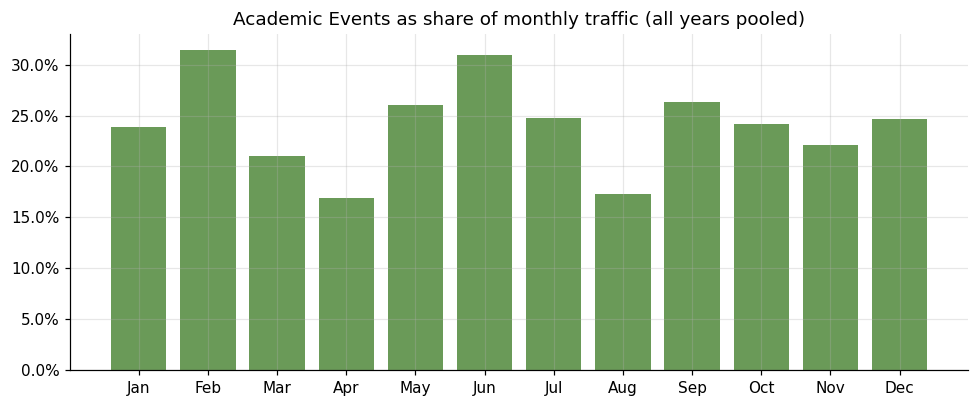

Date_parsed
1     23.8
2     31.4
3     21.0
4     16.9
5     26.0
6     30.9
7     24.7
8     17.3
9     26.3
10    24.2
11    22.1
12    24.6


In [9]:
acad = df[df["major_topic"] == "Academic Events"].copy()
acad_profile = acad.groupby(acad["Date_parsed"].dt.month).size()
overall_profile = df.groupby(df["Date_parsed"].dt.month).size()
share_profile = (acad_profile / overall_profile * 100)

fig, ax = plt.subplots(figsize=(9, 3.8))
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.bar(range(1, 13), share_profile.reindex(range(1, 13), fill_value=0),
       color="#6a9a58")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Academic Events as share of monthly traffic (all years pooled)")
plt.tight_layout()
plt.savefig("fig_academic_seasonality.png", bbox_inches="tight")
plt.show()

print(share_profile.round(1).to_string())